# CGW Overfitting Test: Likelihood vs Assumed Source Count

This notebook empirically characterizes the PTA log-likelihood when the assumed
number of continuous gravitational wave (CGW) sources `M'` differs from the
true injected count `M`.

We:
1. Generate a synthetic 10-pulsar PTA with simple white noise.
2. Inject **M = 2** CGW sources via `CWInjectorStack`.
3. For each `M' ∈ {0, 1, ..., M+3}`, build a fresh likelihood with M' sources
   and **maximize log L** over its 7·M' CGW parameters using Adam (with random
   restarts).
4. Plot ΔlogL, ΔAIC, ΔBIC vs M' to visualize underfitting (M'<M),
   correct fit (M'=M), and overfitting (M'>M).

Information criteria:
- **AIC** = −2 logL + 2 k
- **BIC** = −2 logL + k · log(N_data)

where k = 7·M' is the parameter count and N_data = N_pulsars · N_TOAs.

In [15]:
%matplotlib widget
import matplotlib.pyplot as plt

In [16]:
from __future__ import annotations
import time
from io import StringIO

from loguru import logger
logger.disable("pint")

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import numpy as np

import astropy.units as u
import pint.models as pm
import pint.simulation as psim

from jaxpint import build_timing_model, pint_toas_to_jax
from jaxpint.bridge.model_conversion import pint_model_to_params
from jaxpint.pta.likelihood import PTAConfig, pta_logL
from jaxpint.pta.params import GlobalParams
from jaxpint.pta.signals.cw import CWInjectorStack, _CW_PARAM_NAMES
from jaxpint.simulation import apply_delay_to_toas

jax.config.update("jax_enable_x64", True)

In [17]:
# ---- Configuration ----
N_PULSARS = 10
N_TOAS = 150
START_MJD = 57000.0
END_MJD = 58826.0       # ~5 yr observation span
TOA_ERROR = 1e-7        # 100 ns
FREQ = 1400.0           # MHz
SEED = 42

# Overfitting-test config
M_TRUE = 2
M_MAX = M_TRUE + 3      # sweep M' from 0..M_MAX inclusive
N_RESTARTS = 20
N_OPT_STEPS = 400
LR = 3e-3

N_DATA = N_PULSARS * N_TOAS
print(f"N_pulsars={N_PULSARS}, N_TOAs/pulsar={N_TOAS}, N_data={N_DATA}")
print(f"M_TRUE={M_TRUE}, sweep M' in 0..{M_MAX}, N_restarts={N_RESTARTS}, "
      f"N_opt_steps={N_OPT_STEPS}, lr={LR}")

N_pulsars=10, N_TOAs/pulsar=150, N_data=1500
M_TRUE=2, sweep M' in 0..5, N_restarts=20, N_opt_steps=400, lr=0.003


## Generate synthetic pulsars

In [18]:
rng = np.random.default_rng(SEED)


def generate_random_par(idx: int, rng: np.random.Generator) -> str:
    """Generate a .par string for a simple spindown + white-noise pulsar."""
    ra_hours = rng.uniform(0, 24)
    dec_deg = np.degrees(np.arcsin(rng.uniform(-1, 1)))

    ra_h = int(ra_hours)
    ra_m = int((ra_hours - ra_h) * 60)
    ra_s = (ra_hours - ra_h - ra_m / 60) * 3600

    dec_sign = "+" if dec_deg >= 0 else "-"
    dec_abs = abs(dec_deg)
    dec_d = int(dec_abs)
    dec_m = int((dec_abs - dec_d) * 60)
    dec_s = (dec_abs - dec_d - dec_m / 60) * 3600

    f0 = rng.uniform(100, 500)
    f1 = -10 ** rng.uniform(-16, -14)
    px_kpc = rng.uniform(0.5, 3.0)

    return f"""\
PSR           J{ra_h:02d}{ra_m:02d}{dec_sign}{dec_d:02d}{dec_m:02d}_{idx:02d}
RAJ           {ra_h:02d}:{ra_m:02d}:{ra_s:08.5f}
DECJ          {dec_sign}{dec_d:02d}:{dec_m:02d}:{dec_s:07.4f}
F0            {f0:.10f}
F1            {f1:.6e}
PEPOCH        {START_MJD:.1f}
PX            {px_kpc:.4f}
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
"""


par_strings = [generate_random_par(i, rng) for i in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]
print(f"Generated {N_PULSARS} pulsars")

Generated 10 pulsars


In [19]:
toa_data_list = []
pulsar_params_list = []
timing_models = []
noise_models = []

for i, model in enumerate(pint_models):
    toas = psim.make_fake_toas_uniform(
        START_MJD, END_MJD, N_TOAS, model,
        obs="GBT", error=TOA_ERROR * u.s, freq=FREQ * u.MHz,
    )
    toa_data = pint_toas_to_jax(toas, model)
    par_result = pint_model_to_params(model)
    tm, nm = build_timing_model(model, toas)
    toa_data_list.append(toa_data)
    pulsar_params_list.append(par_result.params)
    timing_models.append(tm)
    noise_models.append(nm)

print(f"All {N_PULSARS} pulsars converted to JaxPINT.")

All 10 pulsars converted to JaxPINT.


In [20]:
# Pulsar unit vectors from RAJ/DECJ for CW antenna patterns.
positions_np = []
for model in pint_models:
    ra_rad = model.RAJ.quantity.to(u.rad).value
    dec_rad = model.DECJ.quantity.to(u.rad).value
    positions_np.append(np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad),
    ]))
positions = jnp.array(np.array(positions_np))
print(f"positions shape = {positions.shape}")

positions shape = (10, 3)


## Inject M_TRUE CGW sources into the TOAs

In [21]:
# Sample truth parameters for M_TRUE CGW sources from the same priors
# we'll use for restart sampling -- keeps the test self-consistent.
truth_specs = []
for m in range(M_TRUE):
    truth_specs.append({
        "log10_h":     float(rng.uniform(-15.0, -13.0)),
        "cos_gwtheta": float(rng.uniform(-1.0, 1.0)),
        "gwphi":       float(rng.uniform(0.0, 2 * np.pi)),
        "log10_fgw":   float(rng.uniform(-9.0, -7.0)),
        "cos_inc":     float(rng.uniform(-1.0, 1.0)),
        "psi":         float(rng.uniform(0.0, np.pi)),
        "phase0":      float(rng.uniform(0.0, 2 * np.pi)),
    })

print("Truth CGW source parameters:")
for m, spec in enumerate(truth_specs):
    print(f"  source {m}: " + ", ".join(f"{k}={v:+.3f}" for k, v in spec.items()))

truth_inj = CWInjectorStack(positions, n_sources=M_TRUE,
                            per_source_values=truth_specs)
gp_truth = truth_inj.register_params(GlobalParams.empty())

injected_toa_data_list = []
for i in range(N_PULSARS):
    td = toa_data_list[i]
    delay = truth_inj.delay(i, td, pulsar_params_list[i], gp_truth)
    injected_toa_data_list.append(apply_delay_to_toas(td, delay))

pp_tuple = tuple(pulsar_params_list)
print(f"\nInjected {M_TRUE} CGW sources into {N_PULSARS} pulsars.")

Truth CGW source parameters:
  source 0: log10_h=-14.600, cos_gwtheta=-0.985, gwphi=+4.944, log10_fgw=-7.670, cos_inc=+0.410, psi=+2.453, phase0=+2.883
  source 1: log10_h=-13.863, cos_gwtheta=-0.720, gwphi=+0.720, log10_fgw=-7.663, cos_inc=-0.058, psi=+1.776, phase0=+4.807

Injected 2 CGW sources into 10 pulsars.


## Helpers: per-M' likelihood, Adam loop, prior sampling

In [22]:
def make_logL_fn(m_prime: int):
    """Build a JAX log-likelihood callable for an M'-source assumed model.

    Returns
    -------
    For ``m_prime == 0``: a single Python float (no params to optimize).
    Otherwise: ``(neg_logL, gp0, config)`` where
    ``neg_logL : (7*m_prime,) -> scalar`` is differentiable & jittable.
    """
    if m_prime == 0:
        config0 = PTAConfig(
            toa_data_list=tuple(injected_toa_data_list),
            timing_models=tuple(timing_models),
            noise_models=tuple(noise_models),
            signal_injectors=(),
        )
        return float(pta_logL(GlobalParams.empty(), pp_tuple, config0))

    inj = CWInjectorStack(positions, n_sources=m_prime)
    gp0 = inj.register_params(GlobalParams.empty())
    config = PTAConfig(
        toa_data_list=tuple(injected_toa_data_list),
        timing_models=tuple(timing_models),
        noise_models=tuple(noise_models),
        signal_injectors=(inj,),
    )

    # CW params occupy gp0.values[0 : 7*m_prime] in (_CW_PARAM_NAMES x sources)
    # order; eqx.tree_at swaps the whole values array in one op.
    def neg_logL(theta_flat):
        gp = eqx.tree_at(lambda g: g.values, gp0, theta_flat)
        return -pta_logL(gp, pp_tuple, config)

    return neg_logL, gp0, config

In [23]:
def make_fit_batch(neg_logL):
    """Build a JIT'd, vmapped Adam fitter over restarts.

    Returns ``fit_batch(thetas0)`` -> ``(thetas_final, logLs)``.
    """
    opt = optax.adam(LR)

    def _adam_loop(theta0):
        state0 = opt.init(theta0)

        def step(_, carry):
            theta, state = carry
            _, g = jax.value_and_grad(neg_logL)(theta)
            updates, state = opt.update(g, state, theta)
            return (optax.apply_updates(theta, updates), state)

        theta_final, _ = jax.lax.fori_loop(
            0, N_OPT_STEPS, step, (theta0, state0)
        )
        return theta_final, -neg_logL(theta_final)  # logL (positive)

    @jax.jit
    def fit_batch(thetas0):  # (R, D) -> ((R, D), (R,))
        return jax.vmap(_adam_loop)(thetas0)

    return fit_batch

In [24]:
def sample_init(key, m_prime: int):
    """Draw a flat (7*m_prime,) initial guess from the prior.

    Order matches ``_CW_PARAM_NAMES`` per source:
        (log10_h, cos_gwtheta, gwphi, log10_fgw, cos_inc, psi, phase0)
    so ``theta[7*m : 7*(m+1)]`` is the param vector for source m.
    """
    keys = jax.random.split(key, 7)
    PI = jnp.pi
    cols = [
        jax.random.uniform(keys[0], (m_prime,), minval=-15.0, maxval=-13.0),  # log10_h
        jax.random.uniform(keys[1], (m_prime,), minval=-1.0,  maxval=1.0),    # cos_gwtheta
        jax.random.uniform(keys[2], (m_prime,), minval=0.0,   maxval=2*PI),   # gwphi
        jax.random.uniform(keys[3], (m_prime,), minval=-9.0,  maxval=-7.0),   # log10_fgw
        jax.random.uniform(keys[4], (m_prime,), minval=-1.0,  maxval=1.0),    # cos_inc
        jax.random.uniform(keys[5], (m_prime,), minval=0.0,   maxval=PI),     # psi
        jax.random.uniform(keys[6], (m_prime,), minval=0.0,   maxval=2*PI),   # phase0
    ]
    return jnp.stack(cols, axis=-1).reshape(-1)

## Sweep M' from 0 to M_MAX

In [25]:
logL_max = np.zeros(M_MAX + 1)
best_theta: dict[int, np.ndarray] = {}

for m_prime in range(M_MAX + 1):
    t0 = time.perf_counter()

    if m_prime == 0:
        logL_max[m_prime] = make_logL_fn(0)
        elapsed = time.perf_counter() - t0
        print(f"  M'={m_prime}: logL = {logL_max[m_prime]:+12.2f}  "
              f"(baseline, no opt) [{elapsed:5.1f}s]")
        continue

    neg_logL, gp0, config = make_logL_fn(m_prime)
    fit_batch = make_fit_batch(neg_logL)

    keys = jax.random.split(jax.random.PRNGKey(SEED + m_prime), N_RESTARTS)
    thetas0 = jnp.stack([sample_init(k, m_prime) for k in keys])

    thetas_final, logLs = fit_batch(thetas0)
    thetas_final.block_until_ready()
    logLs_np = np.asarray(logLs)
    elapsed = time.perf_counter() - t0

    n_nan = int(np.isnan(logLs_np).sum())
    if n_nan == N_RESTARTS:
        logL_max[m_prime] = np.nan
        best_theta[m_prime] = np.full((m_prime, 7), np.nan)
        print(f"  M'={m_prime}: ALL {N_RESTARTS} restarts produced NaN -- skipping  [{elapsed:5.1f}s]")
        continue

    best = int(np.nanargmax(logLs_np))
    logL_max[m_prime] = float(logLs_np[best])
    best_theta[m_prime] = np.asarray(thetas_final[best]).reshape(m_prime, 7)

    restart_str = np.array2string(
        logLs_np, precision=1, separator=", ",
        formatter={"float_kind": lambda x: f"{x:+.1f}" if np.isfinite(x) else "  nan"},
    )
    nan_note = f"  ({n_nan}/{N_RESTARTS} NaN)" if n_nan else ""
    print(f"  M'={m_prime}: logL_max = {logL_max[m_prime]:+12.2f}  "
          f"restarts={restart_str}{nan_note}  [{elapsed:5.1f}s]")

/tmp/ipykernel_93981/4220614039.py:11: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config0 = PTAConfig(


  M'=0: logL =    +22692.58  (baseline, no opt) [  6.4s]


/tmp/ipykernel_93981/4220614039.py:21: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config = PTAConfig(


  M'=1: logL_max =    +22693.17  restarts=[+22512.4, +21654.5, +22687.4, +22691.9, +22691.1, +22692.0, +22647.3,
 +22691.5, +22558.1, +22690.7, +7741.5, +22681.7, +22693.1, +22692.2,
 +22693.2, +19087.6, +22666.4, +22659.1, +22586.3, +22071.0]  [ 17.9s]
  M'=2: logL_max =    +22679.71  restarts=[+22464.7, +22595.0, +22594.3, +22619.6, +22604.8, +22627.0, +22629.7,
 +22061.0, +22538.6, +22273.9, +22643.7, +22438.3, +21880.6, +22268.2,
 +2860.1, +16864.8, +22679.7, -35747.0, +22551.9, +21938.5]  [ 13.9s]
  M'=3: logL_max =    +22686.21  restarts=[+22092.1, +22686.2, +22645.8, +22629.7, +20542.6, -9449.5, +11513.3,
 +17997.4, +22653.9, +22431.9, +22659.3, +21903.2, +22642.5, +22682.4,
 +19960.1, +15595.8,   nan, +22057.3, +5765.2, +18074.4]  (1/20 NaN)  [ 13.1s]
  M'=4: logL_max =    +22683.78  restarts=[+22545.3, +22585.3, +22629.6, +20469.7,   nan, +20561.8, +22132.1,
 +22683.8, +21621.4, +10948.8, -70501.5, +21083.3, +22406.4, +22203.4,
 +18304.7, +22557.1, +21300.7, +22204.6, +7611.7,

In [26]:
m_grid = np.arange(M_MAX + 1)
k_arr = 7 * m_grid
AIC = -2 * logL_max + 2 * k_arr
BIC = -2 * logL_max + k_arr * np.log(N_DATA)

print(f"{"M'":>4}  {'logL':>12}  {'AIC':>12}  {'BIC':>12}  "
      f"{'ΔAIC':>8}  {'ΔBIC':>8}")
print("-" * 70)
for m in m_grid:
    print(f"{m:>4}  {logL_max[m]:>+12.2f}  {AIC[m]:>+12.2f}  {BIC[m]:>+12.2f}  "
          f"{AIC[m]-AIC.min():>+8.2f}  {BIC[m]-BIC.min():>+8.2f}")

print(f"\nBIC.argmin = {int(np.argmin(BIC))}   (truth M = {M_TRUE})")
print(f"AIC.argmin = {int(np.argmin(AIC))}")

  M'          logL           AIC           BIC      ΔAIC      ΔBIC
----------------------------------------------------------------------
   0     +22692.58     -45385.16     -45385.16     +0.00     +0.00
   1     +22693.17     -45372.35     -45335.16    +12.81    +50.00
   2     +22679.71     -45331.43     -45257.04    +53.73   +128.11
   3     +22686.21     -45330.41     -45218.84    +54.74   +166.32
   4     +22683.78     -45311.56     -45162.79    +73.59   +222.36
   5     +22689.61     -45309.21     -45123.25    +75.94   +261.91

BIC.argmin = 0   (truth M = 2)
AIC.argmin = 0


## Plot Δ log L, Δ AIC, Δ BIC vs M'

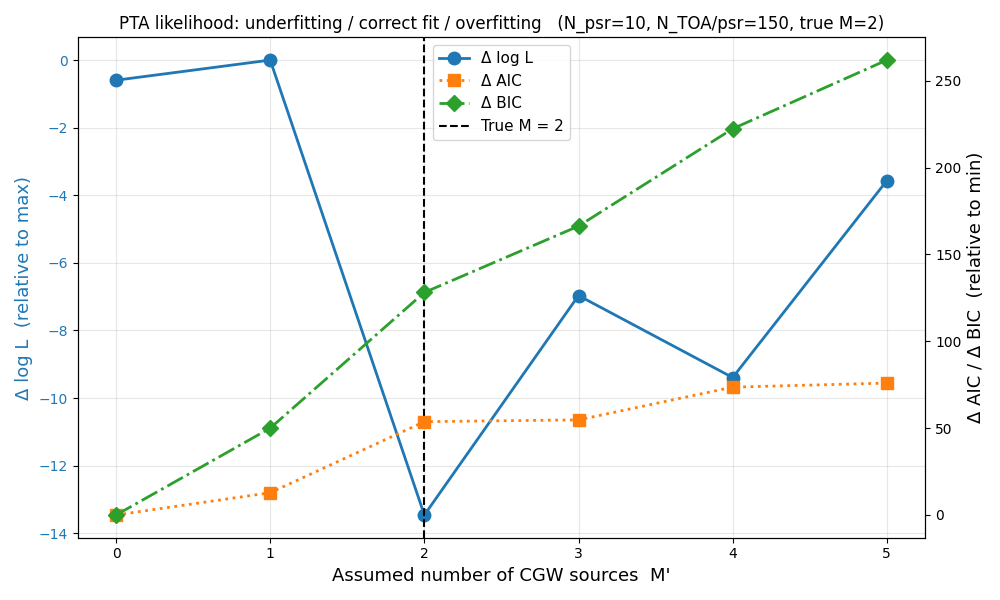

In [27]:
fig, ax_left = plt.subplots(figsize=(10, 6))
ax_right = ax_left.twinx()

dlogL = logL_max - logL_max.max()
dAIC = AIC - AIC.min()
dBIC = BIC - BIC.min()

l1, = ax_left.plot(m_grid, dlogL, 'o-', color='C0', linewidth=2,
                   markersize=9, label='Δ log L')
l2, = ax_right.plot(m_grid, dAIC, 's:', color='C1', linewidth=2,
                    markersize=8, label='Δ AIC')
l3, = ax_right.plot(m_grid, dBIC, 'D-.', color='C2', linewidth=2,
                    markersize=8, label='Δ BIC')
vline = ax_left.axvline(M_TRUE, color='black', linestyle='--', linewidth=1.5,
                        label=f'True M = {M_TRUE}')

ax_left.set_xlabel("Assumed number of CGW sources  M'", fontsize=13)
ax_left.set_ylabel("Δ log L  (relative to max)", color='C0', fontsize=13)
ax_right.set_ylabel("Δ AIC / Δ BIC  (relative to min)", fontsize=13)
ax_left.set_title(
    "PTA likelihood: underfitting / correct fit / overfitting   "
    f"(N_psr={N_PULSARS}, N_TOA/psr={N_TOAS}, true M={M_TRUE})",
    fontsize=12,
)
ax_left.set_xticks(m_grid)
ax_left.tick_params(axis='y', labelcolor='C0')
ax_left.grid(alpha=0.3)

ax_left.legend(handles=[l1, l2, l3, vline], loc='upper center', fontsize=11)
fig.tight_layout()
plt.show()

## Diagnostics: recovered vs true parameters at M' = M_TRUE

In [28]:
print(f"Recovered CGW sources at M' = {M_TRUE} (best of {N_RESTARTS} restarts):\n")
recovered = best_theta[M_TRUE]
for m in range(M_TRUE):
    print(f"  recovered source {m}:")
    for i, name in enumerate(_CW_PARAM_NAMES):
        print(f"    {name:>12s} = {recovered[m, i]:+.4f}")
    print()

print("True CGW sources:\n")
for m, spec in enumerate(truth_specs):
    print(f"  truth source {m}:")
    for name in _CW_PARAM_NAMES:
        print(f"    {name:>12s} = {spec[name]:+.4f}")
    print()

print("Note: source ordering and (psi, phase0) values may differ due to "
      "permutation and (psi -> psi + pi/2, phase0 -> phase0 + pi) degeneracies.")

Recovered CGW sources at M' = 2 (best of 20 restarts):

  recovered source 0:
         log10_h = -15.1237
     cos_gwtheta = +0.8551
           gwphi = +2.5874
       log10_fgw = -7.8977
         cos_inc = -0.1157
             psi = +2.6608
          phase0 = +3.6449

  recovered source 1:
         log10_h = -13.6674
     cos_gwtheta = -0.9805
           gwphi = +1.7643
       log10_fgw = -7.2518
         cos_inc = -0.0890
             psi = +1.2961
          phase0 = +0.0134

True CGW sources:

  truth source 0:
         log10_h = -14.6002
     cos_gwtheta = -0.9853
           gwphi = +4.9444
       log10_fgw = -7.6703
         cos_inc = +0.4103
             psi = +2.4527
          phase0 = +2.8835

  truth source 1:
         log10_h = -13.8625
     cos_gwtheta = -0.7204
           gwphi = +0.7196
       log10_fgw = -7.6632
         cos_inc = -0.0578
             psi = +1.7757
          phase0 = +4.8066

Note: source ordering and (psi, phase0) values may differ due to permutation and 